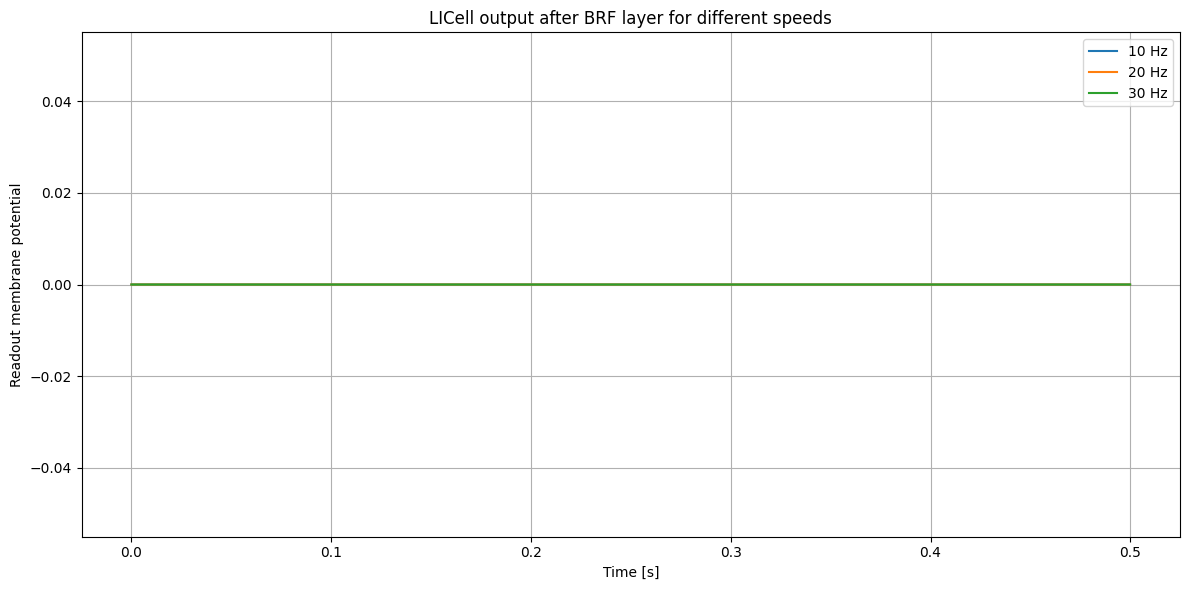

In [2]:
import torch
import matplotlib.pyplot as plt
from brf_lightning.models.backbones import BRFStackedEncoder

# Settings
fs = 8192
dt = 1 / fs
T = int(0.5 * fs)  # 0.5 seconds
t = torch.arange(T) * dt

# Speeds (Hz)
speeds = [10.0, 20.0, 30.0]  # corresponds to 600 / 1200 / 1800 RPM

# Fault order
fault_order = 6.0  # common order for inner race damage

# Use one speed sample per batch
B = len(speeds)

# Inject amplitude-modulated sine wave at different speeds
x = torch.zeros((T, B, 1))
speed_tensor = torch.tensor(speeds).unsqueeze(-1)

for b, f_r in enumerate(speeds):
    carrier = torch.sin(2 * torch.pi * 1800.0 * t)  # constant carrier
    mod_freq = f_r * fault_order
    envelope = 0.5 * (1 + torch.sin(2 * torch.pi * mod_freq * t))
    signal = envelope * carrier
    x[:, b, 0] = signal

# BRF encoder setup
f0s = [1200, 1800, 2400]
Q = 2.0
model = BRFStackedEncoder(f0s=f0s, Q=Q, fs=fs)

# Forward pass
with torch.no_grad():
    y = model(x)  # (T, B, C)

# Plot spike traces
plt.figure(figsize=(12, 6))
for b, f_r in enumerate(speeds):
    plt.plot(t, y[:, b, 0], label=f'{f_r:.0f} Hz')
plt.title("LICell output after BRF layer for different speeds")
plt.xlabel("Time [s]")
plt.ylabel("Readout membrane potential")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
